**Initial Set-Up**

1. Install Anaconda3 using GUI installer/install Miniforge

2. Run installation commands to install Mamba

    conda config --add channels conda-forge

    conda update -n base --all

    conda install -n base mamba


3. Use Mamba to install PyImageJ
    mamba install -c conda-forge pyimagej openjdk=11

**OR, use Pip**

    Install Python 3
    
    Install OpenJDK 8 or OpenJDK 11

    Install Maven

    Run: pip install pyimagej


**Errors Encountered Previously and Currently**

Install Java
   IF: You recieve an error indicating the program's inability to resolve Java, 
   then install the official Java Development Kit (JDK from the website) 
   https://www.oracle.com/java/technologies/downloads/?er=221886#jdk25. 

Original ImageJ not available    
 - Do not change initialization line. 

Re-running cell with initialization code (see below) leads to problems with initialization.
 - Guarding implemented ("if 'ij' not in globals()...")

 **Todo** 
  - Take measurements from an image and append to a .csv file --> complete
  - Implement looping through a folder. --> complete
  - Dump csv --> .pkl file --> complete
  - Implement particle analysis --> complete
  - Cross-reference results w/ pickle files

In [1]:
# ! mamba remove -n base pyimagej
# ! pip install pyimagej

from IPython.display import Image, display
from pathlib import Path
import jpype
import imagej
import scyjava
from scyjava import jimport
import pandas as pd
import numpy as np
import os

print("Dependencies present")


# Set Random Image for Testing
test_image_pth = "content/Images1/noise 3 21001.0.png"

# Pre-sets
path_in1 = "./content/Images1/"
path_in2 = "./content/Images2/"
path_in3 = "./content/Images3/"

path_out_csv = "./data/feats_extracted.csv"

# Set Java heap size = 6 gb.
# scyjava.config.add_option('-Xmx6g')

# Folder containing PNG images
# Select one of the input paths (path_in1, path_in2, path_in3)
input_dir = path_in2
output_csv = Path(path_out_csv)

print("I/O Set.")

Dependencies present
I/O Set.


In [2]:
print(f"Analyzing measurements on all images from folder {input_dir}")

# Initialize ImageJ
# Java Virtual Machine Guarding
if 'ij' not in globals():
    ij = imagej.init('sc.fiji:fiji', headless=False, add_legacy=True)
else:
    print("JVM instance already running.")

print(f"Ensure ImageJ Legacy layer is available. Status: {ij.legacy.isActive()}")


## Clear 
ij.IJ.run("Clear Results")
Summary = ij.ResultsTable.getResultsTable("Summary")
if Summary is not None:
    Summary.reset()

counter = 0
for file in os.listdir(input_dir):
    counter += 1
    
    if counter % 1000 == 0:
        print(counter)

    # Can be deleted for production purposes later. Implemented for efficiency.
    if counter > 2000:
        break

    full_path = str(input_dir) + '/' + file

    # Load test image
    dataset = ij.IJ.openImage(full_path)

    # Display the image within Jupyter Lab for intuitive purposes 
    #display(Image(full_path))

    # Select entire image
    ij.IJ.run(dataset, "Select All", "")

    # Set Measurements
    ij.IJ.run("Set Measurements...", """area mean standard modal min centroid center perimeter bounding fit shape feret's integrated median skewness kurtosis area_fraction stack display add redirect=None decimal=3""")

    # Extract Measurements from the image
    ij.IJ.run(dataset, "Measure", "")   

# Get Results 
ResultsTable = ij.ResultsTable.getResultsTable()

# Returns tab delimited. .split ensure grouping
cols = list(ResultsTable.getColumnHeadings().split('\t'))
cols.remove(' ')

all_data = {}

for col in cols:
    col = str(col)
    if col == 'Label':
        col_data = [ResultsTable.getStringValue(col, i) for i in range(ResultsTable.size())]
        for i in range(len(col_data)):
            col_data[i] = str(col_data[i])
        all_data[col] = col_data
    else:
        col_data = ResultsTable.getColumn(col)
        all_data[col] = col_data

feats_extracted_df = pd.DataFrame(data=all_data)
feats_extracted_df.rename(columns={'Label' : 'Path'}, inplace=True)
feats_extracted_df['Dir'] = f'{input_dir}'


feats_extracted_df

The headless flag of imagej.init is deprecated. Use the mode argument instead.


Analyzing measurements on all images from folder ./content/Images2/
Ensure ImageJ Legacy layer is available. Status: True
1000
2000


,Path,Area,Mean,StdDev,Mode,Min,Max,X,Y,XM,...,RawIntDen,Slice,FeretX,FeretY,FeretAngle,MinFeret,AR,Round,Solidity,Dir
0,noise 3 20401.0.png,40000.0,0.000000,0.000000,0.0,0.0,0.0,100.0,100.0,100.000000,...,0.0,1.0,0.0,0.0,135.0,200.0,1.0,1.0,1.0,./content/Images2/
1,noise 3 20402.0.png,40000.0,18.729750,66.523630,0.0,0.0,255.0,100.0,100.0,108.868618,...,749190.0,1.0,0.0,0.0,135.0,200.0,1.0,1.0,1.0,./content/Images2/
2,noise 3 20403.0.png,40000.0,255.000000,0.000000,255.0,255.0,255.0,100.0,100.0,100.000000,...,10200000.0,1.0,0.0,0.0,135.0,200.0,1.0,1.0,1.0,./content/Images2/
3,noise 3 20404.0.png,40000.0,255.000000,0.000000,255.0,255.0,255.0,100.0,100.0,100.000000,...,10200000.0,1.0,0.0,0.0,135.0,200.0,1.0,1.0,1.0,./content/Images2/
4,noise 3 20405.0.png,40000.0,251.538375,29.508529,255.0,0.0,255.0,100.0,100.0,99.913742,...,10061535.0,1.0,0.0,0.0,135.0,200.0,1.0,1.0,1.0,./content/Images2/
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,noise 5 22470.0.png,40000.0,200.774250,104.342736,255.0,0.0,255.0,100.0,100.0,100.120182,...,8030970.0,1.0,0.0,0.0,135.0,200.0,1.0,1.0,1.0,./content/Images2/
1996,noise 5 22471.0.png,40000.0,0.000000,0.000000,0.0,0.0,0.0,100.0,100.0,100.000000,...,0.0,1.0,0.0,0.0,135.0,200.0,1.0,1.0,1.0,./content/Images2/
1997,noise 5 22472.0.png,40000.0,4.169250,32.338866,0.0,0.0,255.0,100.0,100.0,100.983180,...,166770.0,1.0,0.0,0.0,135.0,200.0,1.0,1.0,1.0,./content/Images2/
1998,noise 5 22473.0.png,40000.0,0.000000,0.000000,0.0,0.0,0.0,100.0,100.0,100.000000,...,0.0,1.0,0.0,0.0,135.0,200.0,1.0,1.0,1.0,./content/Images2/


In [3]:
os.getcwd()

'c:\\Users\\user.SR7872\\Documents\\Github\\PatternsFormation\\FINAL'

In [4]:
test_csv = './Tests/test_feats_csv.csv'
feats_extracted_df.to_csv(test_csv)

In [80]:
print(f"Analyzing measurements on all images from folder {input_dir}")

# Initialize ImageJ
# Java Virtual Machine Guarding
if 'ij' not in globals():
    ij = imagej.init('sc.fiji:fiji', headless=False, add_legacy=True)
else:
    print("JVM instance already running.")

print(f"Ensure ImageJ Legacy layer is available. Status: {ij.legacy.isActive()}")

## Clear 
ij.IJ.run("Clear Results")
Summary = ij.ResultsTable.getResultsTable("Summary")
if Summary is not None:
    Summary.reset()

## GET PARTICLE DATA

print("Particle Start...")

print(f"Analyzing measurements on all images from folder {input_dir}")

Prefs = scyjava.jimport('ij.Prefs'); 
Prefs.blackBackground = False


counter = 0
for file in os.listdir(input_dir):
    counter += 1

    if counter % 10 == 0:
        print(counter)

    if counter > 100:
        break

    full_path = str(input_dir) + '/' + file

    # Load test image
    dataset = ij.IJ.openImage(full_path)

    # Select entire image
    ij.IJ.run(dataset, "Select All", "")

    ij.IJ.run(dataset, "8-bit", "")
    # ij.IJ.setAutoThreshold(dataset, "method=Otsu")
    ij.IJ.setAutoThreshold(dataset, "Default")
    ij.IJ.run(dataset, "Convert to Mask", "")

    ij.IJ.run(
        dataset,
        "Analyze Particles...",
        "display clear summarize overlay record"
    )

print("Particles analyzed.")

ResultsTable = ij.ResultsTable.getResultsTable("Summary")

print("Get Summary Table")

# Returns tab delimited. .split ensure grouping
cols = list(ResultsTable.getColumnHeadings().split('\t'))
print(cols)

all_data = {}

for col in cols:
    col = str(col)
    if col == 'Slice':
        col_data = [ResultsTable.getStringValue(col, i) for i in range(ResultsTable.size())]
        for i in range(len(col_data)):
            col_data[i] = str(col_data[i])
        all_data[col] = col_data
    else:
        col_data = ResultsTable.getColumn(col)
        all_data[col] = col_data

particle_summary_df = pd.DataFrame(data=all_data)
particle_summary_df.rename(columns={'Slice' : 'Path'}, inplace=True)
particle_summary_df['dir'] = input_dir


particle_summary_df

Analyzing measurements on all images from folder ./content/Images2/
JVM instance already running.
Ensure ImageJ Legacy layer is available. Status: True
Particle Start...
Analyzing measurements on all images from folder ./content/Images2/
10
20
30
40
50
60
70
80
90
100
Particles analyzed.
Get Summary Table
['Slice', 'Count', 'Total Area', 'Average Size', '%Area', 'Mean', 'Mode', 'Perim.', 'Major', 'Minor', 'Angle', 'Circ.', 'Solidity', 'Feret', 'FeretX', 'FeretY', 'FeretAngle', 'MinFeret', 'IntDen', 'Median', 'Skew', 'Kurt']


,Path,Count,Total Area,Average Size,%Area,Mean,Mode,Perim.,Major,Minor,...,Feret,FeretX,FeretY,FeretAngle,MinFeret,IntDen,Median,Skew,Kurt,dir
0,noise 3 20401.0.png,1.0,40000.0,40000.000000,100.0000,255.0,255.0,797.656860,225.675827,225.675827,...,282.842712,0.000000,0.000000,135.00000,200.000000,1.020000e+07,255.0,NaN,NaN,./content/Images2/
1,noise 3 20402.0.png,1.0,37062.0,37062.000000,92.6550,255.0,255.0,883.823364,217.470444,216.989502,...,282.842712,0.000000,0.000000,135.00000,200.000000,9.450810e+06,255.0,NaN,NaN,./content/Images2/
2,noise 3 20403.0.png,0.0,0.0,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,./content/Images2/
3,noise 3 20404.0.png,0.0,0.0,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,./content/Images2/
4,noise 3 20405.0.png,26.0,543.0,20.884615,1.3575,255.0,255.0,15.420893,5.495724,4.817807,...,6.056007,106.269231,100.692308,117.81557,4.615385,5.325577e+03,255.0,NaN,NaN,./content/Images2/
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,noise 3 20497.0.png,1.0,40000.0,40000.000000,100.0000,255.0,255.0,797.656860,225.675827,225.675827,...,282.842712,0.000000,0.000000,135.00000,200.000000,1.020000e+07,255.0,NaN,NaN,./content/Images2/
96,noise 3 20498.0.png,1.0,40000.0,40000.000000,100.0000,255.0,255.0,797.656860,225.675827,225.675827,...,282.842712,0.000000,0.000000,135.00000,200.000000,1.020000e+07,255.0,NaN,NaN,./content/Images2/
97,noise 3 20499.0.png,0.0,0.0,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,./content/Images2/
98,noise 3 20500.0.png,1.0,40000.0,40000.000000,100.0000,255.0,255.0,797.656860,225.675827,225.675827,...,282.842712,0.000000,0.000000,135.00000,200.000000,1.020000e+07,255.0,NaN,NaN,./content/Images2/


Path: noise 3 20470.0.png     Directory: Images2
num_spots according to unclassified_features.pkl:  150
num spots according to ExtractFeatures.ipynb:  1.0


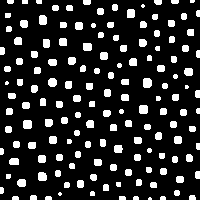

In [81]:
## Use this code snippet to compare values given by two measures.

import IPython.display

path =  'noise 3 20470.0.png'
directory = 'Images2'
full_path = f'./content/{directory}/{path}'

feats_org = pd.read_pickle('./data/unclassified_features.pkl') ## Originally-generated pickle file

part_sum_ns = particle_summary_df[particle_summary_df['Path'] == path]
image_feats = feats_org[feats_org['path'] == path]
print(f"Path: {image_feats[image_feats.columns[9]].item()}     Directory: {directory}")
print("num_spots according to unclassified_features.pkl: ", image_feats[image_feats.columns[13]].item())
print('num spots according to ExtractFeatures.ipynb: ', part_sum_ns['Count'].item())

Image(filename=full_path)